## SVM

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from  load_data import load_images, load_labels
from sklearn import svm
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

In [3]:
# Load data from files
X_T = load_images("../MNIST_dataset/train-images-idx3-ubyte/train-images-idx3-ubyte")
y_T = load_labels("../MNIST_dataset/train-labels-idx1-ubyte/train-labels-idx1-ubyte")

print("Train X shape:", X_T.shape)
print("Train y shape:", y_T.shape)
print("Sample shape:", X_T[0].shape)

Train X shape: (60000, 28, 28)
Train y shape: (60000,)
Sample shape: (28, 28)


In [4]:
#Scale the pixel values to [0, 1]
X_T = X_T / 255.0

In [5]:
# Tran and val split
X_train, X_val, y_train, y_val = train_test_split(X_T, y_T, test_size=(1/6), random_state=42)
print("After split:")
print("Train X shape:", X_train.shape)
print("Train y shape:", y_train.shape)
print("Val X shape:", X_val.shape)
print("Val y shape:", y_val.shape)

After split:
Train X shape: (50000, 28, 28)
Train y shape: (50000,)
Val X shape: (10000, 28, 28)
Val y shape: (10000,)


(Example) Class 0 samples: 4939


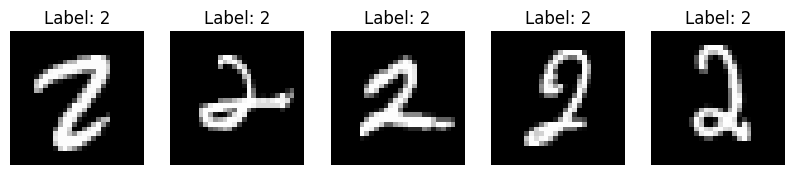

In [6]:
# Filter out all samples into respective classes
class_samples = {}
for i in range(10):
    class_samples[i] = X_train[y_train == i]

print("(Example) Class 0 samples:", class_samples[0].shape[0])

#Display random samples from a class, to check if they are correctly filtered
display_class = 2

fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    axes[i].imshow(class_samples[display_class][np.random.randint(0, class_samples[display_class].shape[0])], cmap='gray')
    axes[i].set_title(f"Label: {list(class_samples.keys())[display_class]}")
    axes[i].axis('off')
plt.show()

In [7]:
# Create inverse classes, to train models with a fair class balance


inverse_class_samples = {}
for i in range(10):
    # Get samples from other classes
    other_samples = X_train[y_train != i]
    np.random.shuffle(other_samples)
    # Take the same number of samples as class i has
    num_samples = class_samples[i].shape[0]
    inverse_class_samples[i] = other_samples[:num_samples]

# Check that all classes match lenghts (just a quick check)
all_clear = True
for i in range(10):
    if class_samples[i].shape[0] != inverse_class_samples[i].shape[0]: all_clear = False
print("All classes have same number of samples:", all_clear)

All classes have same number of samples: True


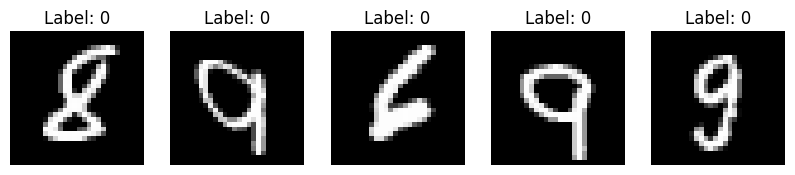

In [8]:
display_class = 0

fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    axes[i].imshow(inverse_class_samples[display_class][np.random.randint(0, inverse_class_samples[display_class].shape[0])], cmap='gray')
    axes[i].set_title(f"Label: {list(inverse_class_samples.keys())[display_class]}")
    axes[i].axis('off')
plt.show()

In [9]:
# Reshape the data for SVM
for i in range(10):
    class_samples[i] = class_samples[i].reshape(class_samples[i].shape[0], -1)
    inverse_class_samples[i] = inverse_class_samples[i].reshape(inverse_class_samples[i].shape[0], -1)
    
    X_val = X_val.reshape(X_val.shape[0], -1)

print("Class 0 samples shape:", class_samples[0].shape[1], "| Expected: 28 x 28 = 784")
print("X_val samples shape:", X_val.shape[1], "  | Expected: 28 x 28 = 784")

Class 0 samples shape: 784 | Expected: 28 x 28 = 784
X_val samples shape: 784   | Expected: 28 x 28 = 784


In [10]:
# Train SVM models for each class vs inverse class
kernel = 'rbf'
C = 1.0

svm_models = {}
for i in range(10):
    new_svm = svm.SVC()
    X_train_combined = np.vstack((class_samples[i], inverse_class_samples[i]))
    y_train_combined = np.hstack((np.ones(class_samples[i].shape[0]), np.zeros(inverse_class_samples[i].shape[0])))
    new_svm.fit(X_train_combined, y_train_combined)
    svm_models[i] = new_svm
    print(f"Trained {i + 1} / 10 SVM models")


Trained 1 / 10 SVM models
Trained 2 / 10 SVM models
Trained 3 / 10 SVM models
Trained 4 / 10 SVM models
Trained 5 / 10 SVM models
Trained 6 / 10 SVM models
Trained 7 / 10 SVM models
Trained 8 / 10 SVM models
Trained 9 / 10 SVM models
Trained 10 / 10 SVM models


In [11]:
# test the models on the validation set
num_samples = len(X_val)  # Change this to test on more/fewer samples
samples = X_val[:num_samples]
labels = y_val[:num_samples]

y_pred = []
for i, sample in enumerate(samples):
    # Get decision function values from all 10 models
    decisions = [svm_models[m].decision_function(sample.reshape(1, -1))[0] for m in range(10)]
    # Predict the class with the highest decision value
    predicted_class = np.argmax(decisions)
    y_pred.append(predicted_class)

    print(f"Sample {i+1} / {num_samples}", end='\r')


y_pred = np.array(y_pred)

# Evaluate the model
print(f"Accuracy: {accuracy_score(labels, y_pred)}")
#print("Predicted labels:", y_pred)
#print("True labels:", labels)

Accuracy: 0.97120000


In [12]:
print("Kernel:\t", svm_models[0].kernel)
print("C:\t", svm_models[0].C)
print("Gamma:\t", svm_models[0].gamma)

Kernel:	 rbf
C:	 1.0
Gamma:	 scale


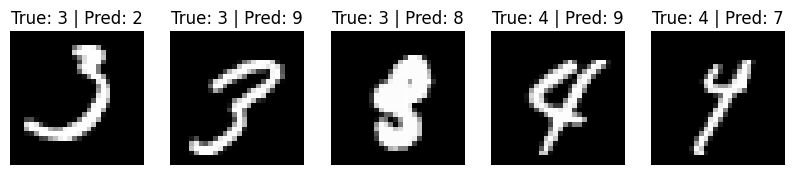

In [65]:
# Plot wrong predictions, randomly select 5 of them to display

fig, axes = plt.subplots(1, 5, figsize=(10, 2))
wrong_indices = np.where(y_pred != labels)[0]
np.random.shuffle(wrong_indices)
wrong_indices = wrong_indices[:5]
for i in range(5):
    axes[i].imshow(samples[wrong_indices[i]].reshape(28, 28), cmap='gray')
    axes[i].set_title(f"True: {labels[wrong_indices[i]]} | Pred: {y_pred[wrong_indices[i]]}")
    axes[i].axis('off')
plt.show()

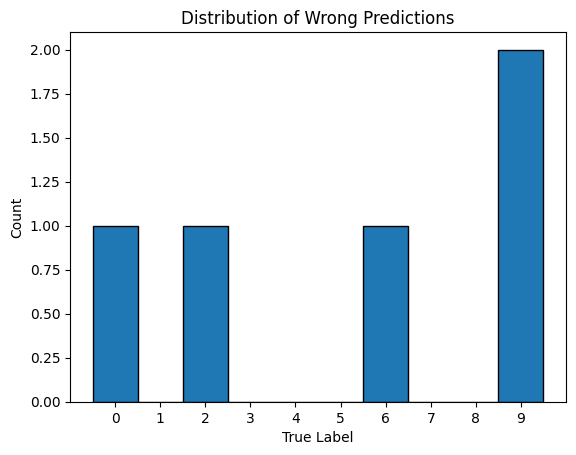

In [14]:
# Plot what the distrobution of wring predicted digets
wrong_labels = labels[wrong_indices]
plt.hist(wrong_labels, bins=np.arange(-0.5, 10.5, 1), edgecolor='black')
plt.xticks(range(10))
plt.xlabel("True Label")
plt.ylabel("Count")
plt.title("Distribution of Wrong Predictions")
plt.show()

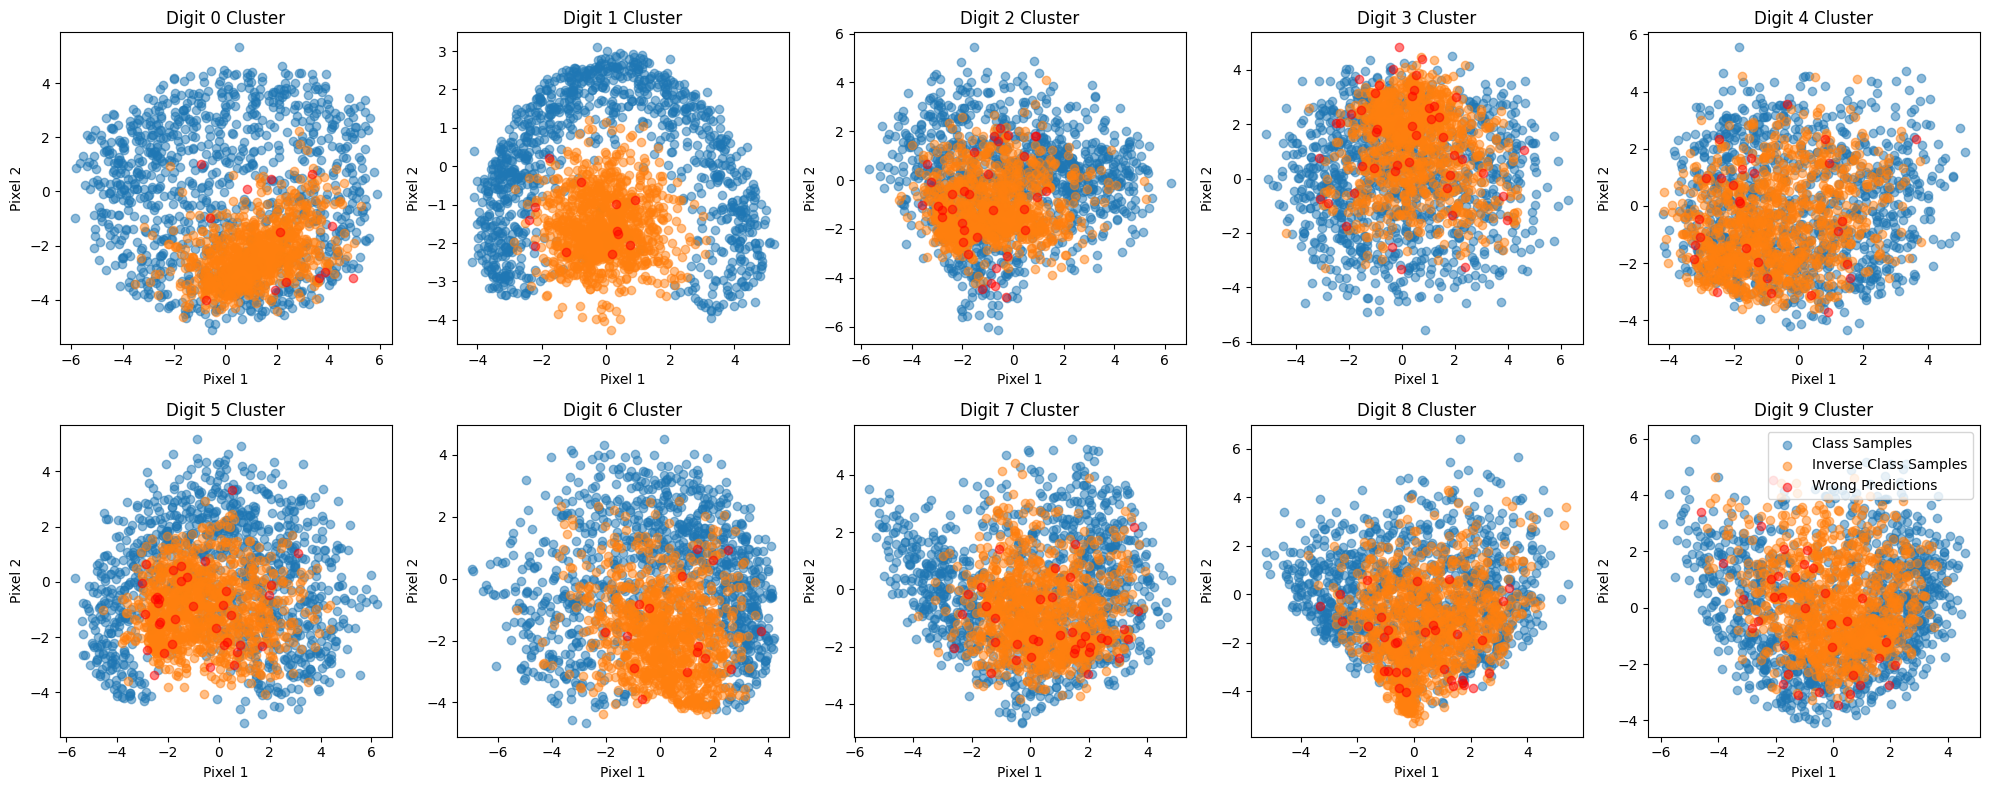

In [18]:
# Plot each didget cluster from class_samples (first 100 samples), and the wrong predicted samples
from sklearn.decomposition import PCA

wrong_indices = np.where(y_pred != labels)[0]
wrong_class_samples = {}
for i in range(10):
    wrong_class_samples[i] = samples[wrong_indices][labels[wrong_indices] == i]

class_samples_pca = {}
inverse_class_samples_pca = {}
wrong_class_samples_pca = {}

for i in range(10):
    pca = PCA(n_components=2)
    class_samples_pca[i] = pca.fit_transform(class_samples[i][0:1000])
    inverse_class_samples_pca[i] = pca.transform(inverse_class_samples[i][0:1000])
    wrong_class_samples_pca[i] = pca.transform(wrong_class_samples[i][0:1000])

figure, axes = plt.subplots(2, 5, figsize=(20, 8))
for i in range(10):
    ax = axes[i // 5, i % 5]
    ax.scatter(class_samples_pca[i][:, 0], class_samples_pca[i][:, 1], alpha=0.5)
    ax.scatter(inverse_class_samples_pca[i][:, 0], inverse_class_samples_pca[i][:, 1], alpha=0.5)
    ax.scatter(wrong_class_samples_pca[i][:, 0], wrong_class_samples_pca[i][:, 1], alpha=0.5, color='red')
    ax.set_title(f"Digit {i} Cluster")
    ax.set_xlabel("Pixel 1")
    ax.set_ylabel("Pixel 2")
    
plt.tight_layout()
plt.legend(["Class Samples", "Inverse Class Samples", "Wrong Predictions"], loc='upper right')
plt.show()